## Project Title: OTT Content Moderation Tagging System

**Introduction**

Online video platforms and OTT services must apply appropriate moderation and safety tags to content for
compliance, parental controls, and user safety. A single content item may require multiple tags at the same time
(for example, content may include violence, strong language, and substance use together). This makes the task a
multi-label classification problem: one input record can map to multiple output labels simultaneously.

**Problem Statement**

Build a Machine Learning model that predicts the appropriate moderation and sensitivity tags for each content
item using structured metadata and computed signals. The model must support multi-label output (predicting
multiple labels for a single record).

**Expected Outcome**

At the end of this project, students should be able to: Frame a business requirement as a multi-label ML problem.
Perform end-to-end EDA, preprocessing, and feature engineering on structured data. Train and compare
multi-label modeling approaches. Evaluate models using multi-label metrics and select the best model based on
evidence.

**Step-by-Step Workflow**

**Step 1: Data Understanding**

Inspect the dataset structure, data types, missing values, and basic statistics. Document observations and
questions to validate during analysis.

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [37]:
df=pd.read_csv("Downloads/ott_content_moderation_multilabel.csv");

In [38]:
df.head()

,content_duration,number_of_fight_scenes,weapon_presence_count,night_scene_ratio,number_of_curse_words,smoking_scene_count,alcohol_scene_count,blood_visibility_score,intimacy_scene_duration,scream_frequency,...,camera_shake_index,audience_age_rating,violence_flag,adult_content_flag,substance_abuse_flag,strong_language_flag,self_harm_flag,disturbing_visuals_flag,political_sensitivity_flag,religious_sensitivity_flag
0,67,2,2,0.319,3,6,7,19,12.5,3,...,27,UA,0,1,1,0,0,0,0,0
1,48,5,3,0.508,0,0,1,32,1.5,4,...,19,UA,1,0,0,0,0,0,0,0
2,24,3,3,0.388,2,0,1,28,0.9,2,...,24,U,0,1,0,0,0,0,0,0
3,98,8,6,0.558,6,2,0,47,12.9,5,...,41,A,1,1,0,1,1,1,1,1
4,45,3,2,0.366,0,1,0,28,0.0,1,...,28,U,1,1,0,0,0,1,0,0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   content_duration             12000 non-null  int64  
 1   number_of_fight_scenes       12000 non-null  int64  
 2   weapon_presence_count        12000 non-null  int64  
 3   night_scene_ratio            12000 non-null  float64
 4   number_of_curse_words        12000 non-null  int64  
 5   smoking_scene_count          12000 non-null  int64  
 6   alcohol_scene_count          12000 non-null  int64  
 7   blood_visibility_score       12000 non-null  int64  
 8   intimacy_scene_duration      12000 non-null  float64
 9   scream_frequency             12000 non-null  int64  
 10  loud_noise_ratio             12000 non-null  float64
 11  disturbing_background_music  12000 non-null  int64  
 12  protest_scene_count          12000 non-null  int64  
 13  religious_symbol

In [40]:
df.describe()

,content_duration,number_of_fight_scenes,weapon_presence_count,night_scene_ratio,number_of_curse_words,smoking_scene_count,alcohol_scene_count,blood_visibility_score,intimacy_scene_duration,scream_frequency,...,crying_scene_duration,camera_shake_index,violence_flag,adult_content_flag,substance_abuse_flag,strong_language_flag,self_harm_flag,disturbing_visuals_flag,political_sensitivity_flag,religious_sensitivity_flag
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,51.018750,3.571583,2.496583,0.424276,5.067833,1.996750,2.319833,28.256833,4.427325,2.022500,...,3.453008,27.813083,0.380833,0.476333,0.529167,0.462250,0.347833,0.374500,0.466083,0.462167
std,21.669226,2.743964,2.142398,0.131300,4.976190,1.983238,2.321886,18.144218,4.633148,1.916151,...,3.647236,14.595943,0.485612,0.499460,0.499169,0.498594,0.476303,0.484014,0.498869,0.498587
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,2.000000,1.000000,0.334000,1.000000,0.000000,0.000000,15.000000,0.500000,0.750000,...,0.100000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,51.000000,3.000000,2.000000,0.417000,4.000000,2.000000,2.000000,25.000000,3.200000,2.000000,...,2.500000,26.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,66.000000,5.000000,4.000000,0.507000,8.000000,3.000000,4.000000,38.000000,6.700000,3.000000,...,5.400000,36.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,135.000000,17.000000,14.000000,0.950000,33.000000,14.000000,15.000000,100.000000,31.700000,15.000000,...,25.400000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [41]:
df.shape

(12000, 25)

In [42]:
df.isnull().sum()

content_duration               0
number_of_fight_scenes         0
weapon_presence_count          0
night_scene_ratio              0
number_of_curse_words          0
smoking_scene_count            0
alcohol_scene_count            0
blood_visibility_score         0
intimacy_scene_duration        0
scream_frequency               0
loud_noise_ratio               0
disturbing_background_music    0
protest_scene_count            0
religious_symbol_presence      0
crying_scene_duration          0
camera_shake_index             0
audience_age_rating            0
violence_flag                  0
adult_content_flag             0
substance_abuse_flag           0
strong_language_flag           0
self_harm_flag                 0
disturbing_visuals_flag        0
political_sensitivity_flag     0
religious_sensitivity_flag     0
dtype: int64

In [43]:
df['audience_age_rating'].value_counts()

audience_age_rating
U     4800
UA    4560
A     2640
Name: count, dtype: int64

**Step 2: Data Cleaning**

Handle missing values, inconsistent entries, and outliers where applicable. Ensure each record is valid and usable
for modeling.

In [44]:
df.isnull().sum()

content_duration               0
number_of_fight_scenes         0
weapon_presence_count          0
night_scene_ratio              0
number_of_curse_words          0
smoking_scene_count            0
alcohol_scene_count            0
blood_visibility_score         0
intimacy_scene_duration        0
scream_frequency               0
loud_noise_ratio               0
disturbing_background_music    0
protest_scene_count            0
religious_symbol_presence      0
crying_scene_duration          0
camera_shake_index             0
audience_age_rating            0
violence_flag                  0
adult_content_flag             0
substance_abuse_flag           0
strong_language_flag           0
self_harm_flag                 0
disturbing_visuals_flag        0
political_sensitivity_flag     0
religious_sensitivity_flag     0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

**Step 3: Exploratory Data Analysis (EDA)**

Perform thorough EDA across the entire dataset: Univariate analysis for every feature (distribution, central
tendency, spread, outliers). Bivariate analysis across meaningful feature pairs (relationships, patterns, potential
dependencies). Target exploration: analyze label frequencies, label imbalance, and the number of labels per
record. Label co-occurrence analysis: identify which labels frequently occur together. Multivariate analysis:
correlation and interaction analysis for numerical features. Note: Students must provide their own interpretations
and insights based on analysis.

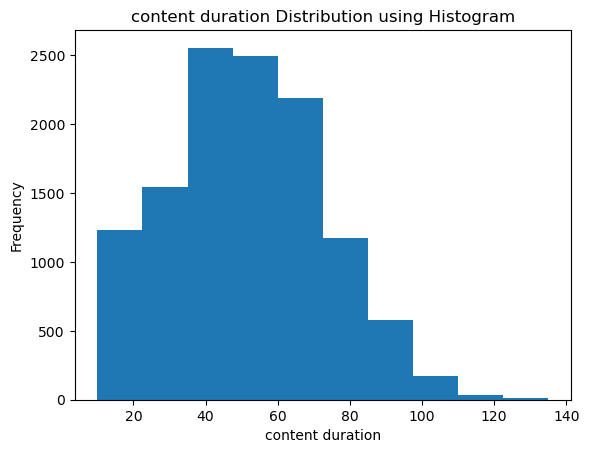

In [46]:
plt.hist(df["content_duration"])
plt.title("content duration Distribution using Histogram")
plt.xlabel("content duration")
plt.ylabel("Frequency")
plt.show()

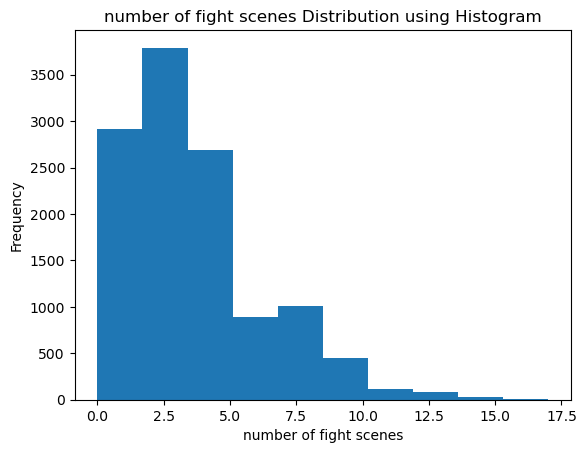

In [47]:
plt.hist(df["number_of_fight_scenes"])
plt.title("number of fight scenes Distribution using Histogram")
plt.xlabel("number of fight scenes")
plt.ylabel("Frequency")
plt.show()

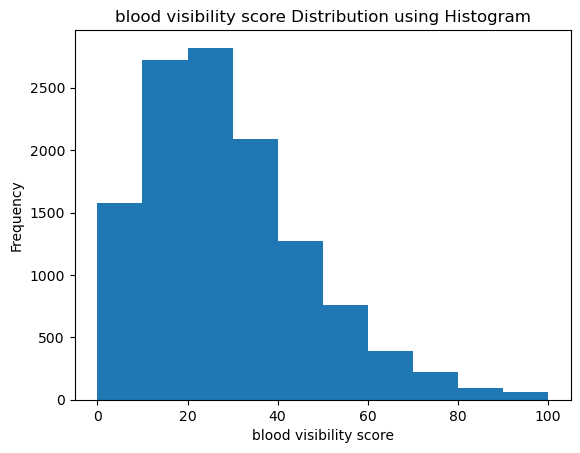

In [48]:
plt.hist(df["blood_visibility_score"])
plt.title("blood visibility score Distribution using Histogram")
plt.xlabel("blood visibility score")
plt.ylabel("Frequency")
plt.show()

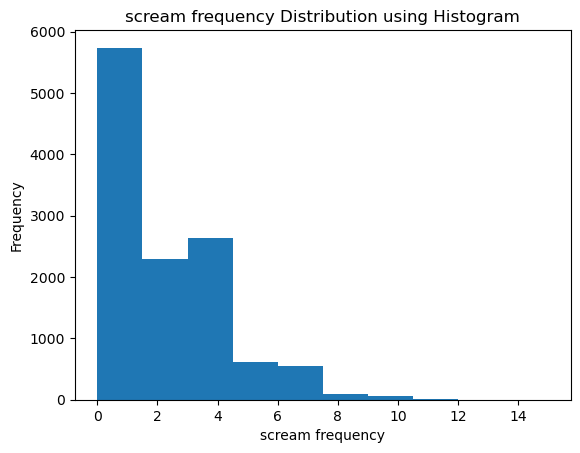

In [49]:
plt.hist(df["scream_frequency"])
plt.title("scream frequency Distribution using Histogram")
plt.xlabel("scream frequency")
plt.ylabel("Frequency")
plt.show()

Box plot

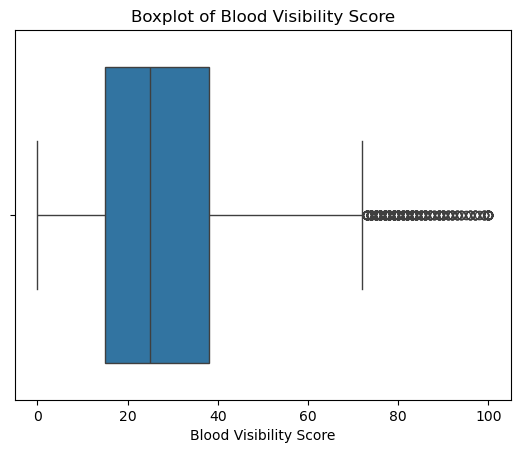

In [50]:
sns.boxplot(x=df['blood_visibility_score'])
plt.title("Boxplot of Blood Visibility Score")
plt.xlabel("Blood Visibility Score")
plt.show()

Count plot

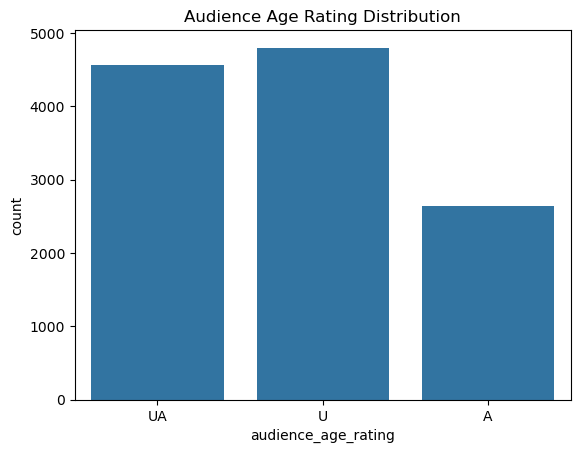

In [51]:
sns.countplot(x='audience_age_rating', data=df)
plt.title("Audience Age Rating Distribution")
plt.show()

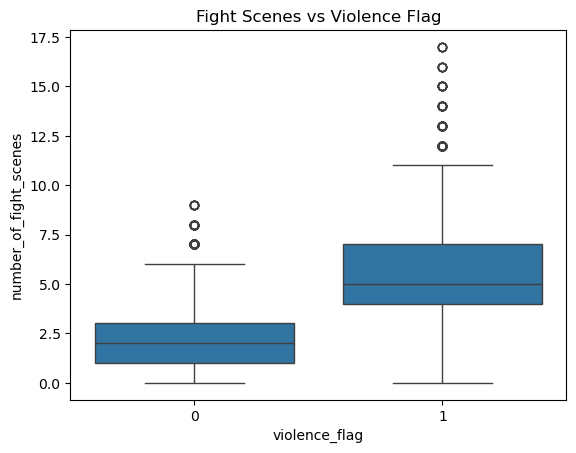

In [52]:
sns.boxplot(x='violence_flag', y='number_of_fight_scenes', data=df)
plt.title("Fight Scenes vs Violence Flag")
plt.show()

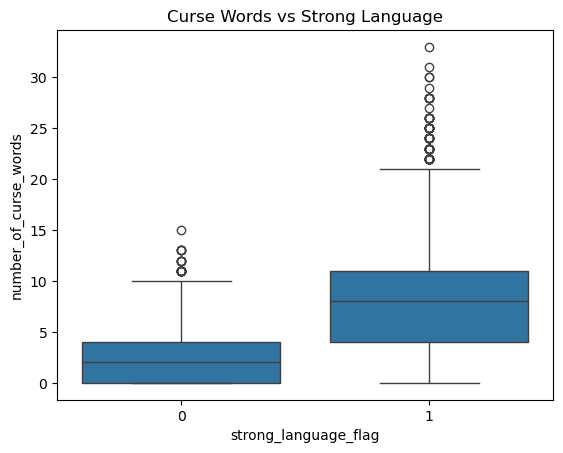

In [53]:
sns.boxplot(x='strong_language_flag', y='number_of_curse_words', data=df)
plt.title("Curse Words vs Strong Language")
plt.show()

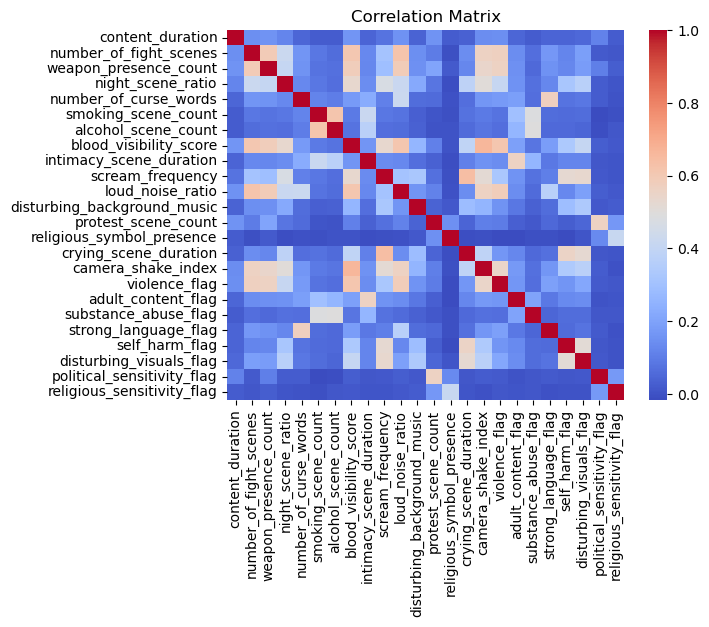

In [54]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Step 4: Multi-Label Target Preparation**

Prepare the label matrix (multi-hot encoding) for training. Ensure the pipeline supports multiple labels per row.

In [67]:
df1=df.copy()

In [68]:
df1.columns

Index(['content_duration', 'number_of_fight_scenes', 'weapon_presence_count',
       'night_scene_ratio', 'number_of_curse_words', 'smoking_scene_count',
       'alcohol_scene_count', 'blood_visibility_score',
       'intimacy_scene_duration', 'scream_frequency', 'loud_noise_ratio',
       'disturbing_background_music', 'protest_scene_count',
       'religious_symbol_presence', 'crying_scene_duration',
       'camera_shake_index', 'audience_age_rating', 'violence_flag',
       'adult_content_flag', 'substance_abuse_flag', 'strong_language_flag',
       'self_harm_flag', 'disturbing_visuals_flag',
       'political_sensitivity_flag', 'religious_sensitivity_flag'],
      dtype='object')

In [113]:
label_columns = ['violence_flag','adult_content_flag','substance_abuse_flag','strong_language_flag','self_harm_flag','disturbing_visuals_flag','political_sensitivity_flag','religious_sensitivity_flag'
]

In [118]:

# target (multi-label)
y = df1[label_columns]

# features
X = df1.drop(columns=label_columns)

In [127]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64','float64']).columns
print("Categorical Columns:", cat_cols)
print("Numeric Columns:", num_cols)

Categorical Columns: Index(['audience_age_rating'], dtype='object')
Numeric Columns: Index(['content_duration', 'number_of_fight_scenes', 'weapon_presence_count',
       'night_scene_ratio', 'number_of_curse_words', 'smoking_scene_count',
       'alcohol_scene_count', 'blood_visibility_score',
       'intimacy_scene_duration', 'scream_frequency', 'loud_noise_ratio',
       'disturbing_background_music', 'protest_scene_count',
       'religious_symbol_presence', 'crying_scene_duration',
       'camera_shake_index'],
      dtype='object')


In [154]:
X_encoded = pd.get_dummies(X, drop_first=True)

**Step 5: Preprocessing Pipeline**

Prepare transformations for numeric, categorical, and binary features (encoding and scaling where required). Use
a reproducible pipeline approach.

In [131]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X_encoded[num_cols])

**Step 6: Train-Test Split**

Split the data into training and testing sets. Ensure the split preserves label characteristics as much as possible.

In [137]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded,y,test_size=0.2,random_state=42)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (9600, 18)
Test set size: (2400, 18)


**Step 7: Model Building (Multi-Label Approaches)**

Implement and compare multiple multi-label strategies, such as: Binary Relevance Classifier Chains Label
Powerset Train multiple base estimators (for example, linear models and tree-based models) and compare
performance.

In [142]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # for loading the ensemble models from sklearn
from sklearn.tree import DecisionTreeClassifier # for loading the decision tree classifier
from xgboost import XGBClassifier # for loading the XGBclassifier from xgboost library
from sklearn.linear_model import LogisticRegression # for loading logisticRegression model from linear models in sklearn
from sklearn.metrics import accuracy_score, classification_report 
from sklearn.multioutput import MultiOutputClassifier

In [139]:
# Random Forest Model
#initializing the random forest classifier
rf_model = RandomForestClassifier(random_state=42)
# training the model on the train sets using fit method
rf_model.fit(X_train, y_train)

# Predictions are made on the test set using predict method
y_pred_rf = rf_model.predict(X_test)

# Evaluating the model 
print("Random Forest Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Classifier:
Accuracy: 0.14583333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.81       958
           1       0.81      0.68      0.74      1154
           2       0.80      0.70      0.75      1302
           3       0.83      0.70      0.76      1117
           4       0.80      0.57      0.67       848
           5       0.80      0.59      0.68       908
           6       0.82      0.62      0.71      1132
           7       0.70      0.52      0.60      1109

   micro avg       0.81      0.64      0.72      8528
   macro avg       0.81      0.64      0.71      8528
weighted avg       0.81      0.64      0.71      8528
 samples avg       0.72      0.59      0.62      8528



In [140]:
# Initialize Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)

# training the model on the train sets using fit method
dt_model.fit(X_train, y_train)

# Predictions are made on the test set using predict method
y_pred_dt = dt_model.predict(X_test)

# Evaluating the model 
print("Decision Tree Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Classifier:
Accuracy: 0.0475

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.69      0.70       958
           1       0.67      0.67      0.67      1154
           2       0.65      0.64      0.65      1302
           3       0.66      0.67      0.66      1117
           4       0.59      0.58      0.58       848
           5       0.60      0.59      0.60       908
           6       0.61      0.62      0.62      1132
           7       0.52      0.53      0.52      1109

   micro avg       0.63      0.62      0.63      8528
   macro avg       0.63      0.62      0.63      8528
weighted avg       0.63      0.62      0.63      8528
 samples avg       0.58      0.59      0.55      8528



In [143]:
# initializing Gradient Boosting Model
gb = GradientBoostingClassifier(random_state=42)
gb_model = MultiOutputClassifier(gb)


# training the model on the train sets using fit method
gb_model.fit(X_train, y_train)

# Predictions are made on the test set using predict method
y_pred_gb = gb_model.predict(X_test)

# Evaluating the model 
print("Gradient Boosting Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Classifier:
Accuracy: 0.16333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.76      0.82       958
           1       0.82      0.69      0.75      1154
           2       0.82      0.69      0.75      1302
           3       0.82      0.70      0.76      1117
           4       0.80      0.63      0.70       848
           5       0.81      0.65      0.72       908
           6       0.81      0.65      0.72      1132
           7       0.76      0.49      0.59      1109

   micro avg       0.82      0.66      0.73      8528
   macro avg       0.82      0.66      0.73      8528
weighted avg       0.82      0.66      0.73      8528
 samples avg       0.73      0.61      0.64      8528



In [144]:
# Initializing XGBoost Model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# training the model on the train sets using fit method
xgb_model.fit(X_train, y_train)

# Predictions are made on the test set using predict method
y_pred_xgb = xgb_model.predict(X_test)

# Evaluating the model 
print("XGBoost Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Classifier:
Accuracy: 0.12875

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.75      0.80       958
           1       0.77      0.69      0.73      1154
           2       0.78      0.70      0.74      1302
           3       0.78      0.71      0.74      1117
           4       0.75      0.62      0.68       848
           5       0.77      0.64      0.70       908
           6       0.76      0.66      0.71      1132
           7       0.65      0.55      0.60      1109

   micro avg       0.76      0.67      0.71      8528
   macro avg       0.76      0.67      0.71      8528
weighted avg       0.76      0.67      0.71      8528
 samples avg       0.69      0.62      0.63      8528



In [146]:
# initializing the Logistic Regression Model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_model = MultiOutputClassifier(lr)

# training the model on the train sets using fit method
lr_model.fit(X_train, y_train)

# Predictions are made on the test set using predict method
y_pred_lr = lr_model.predict(X_test)

# Evaluating the model 
print("Logistic Regression Classifier:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Classifier:
Accuracy: 0.16666666666666666

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.77      0.83       958
           1       0.80      0.71      0.75      1154
           2       0.81      0.71      0.76      1302
           3       0.80      0.73      0.76      1117
           4       0.81      0.62      0.70       848
           5       0.81      0.65      0.72       908
           6       0.79      0.68      0.73      1132
           7       0.78      0.49      0.60      1109

   micro avg       0.81      0.67      0.73      8528
   macro avg       0.81      0.67      0.73      8528
weighted avg       0.81      0.67      0.73      8528
 samples avg       0.73      0.63      0.65      8528



In [149]:
from sklearn.svm import SVC
# Initialize SVM model with a linear kernel
svm = SVC(kernel='linear', random_state=42, probability=True)
svm_model = MultiOutputClassifier(svm)
# Train the model on the training data
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Model Accuracy: {svm_accuracy}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Model Accuracy: 0.17

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.77      0.83       958
           1       0.81      0.71      0.76      1154
           2       0.85      0.67      0.75      1302
           3       0.82      0.72      0.76      1117
           4       0.82      0.60      0.69       848
           5       0.82      0.63      0.71       908
           6       0.80      0.66      0.73      1132
           7       0.79      0.47      0.59      1109

   micro avg       0.83      0.65      0.73      8528
   macro avg       0.82      0.65      0.73      8528
weighted avg       0.82      0.65      0.73      8528
 samples avg       0.74      0.61      0.64      8528



**Step 8: Model Evaluation (Multi-Label Metrics)**

Evaluate and compare models using multi-label metrics such as: Hamming Loss Jaccard Score Micro / Macro F1
Score Subset Accuracy Also include per-label performance where appropriate.

In [150]:
# Train XGBoost on the training set
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

# Evaluate on training set
y_pred_train = xgb_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)
print("XGBoost Training Accuracy:", train_accuracy)

# Evaluate on validation set
y_pred_test = xgb_model.predict(X_test)
val_accuracy = accuracy_score(y_test, y_pred_test)
print("XGBoost Validation Accuracy:", val_accuracy)

# Check for overfitting
if abs(train_accuracy - val_accuracy) > 0.1:
    print("The model is likely overfitting. Consider tuning hyperparameters or using regularization.")
else:
    print("The model shows no significant signs of overfitting and is ready for prediction.")

XGBoost Training Accuracy: 0.7121875
XGBoost Validation Accuracy: 0.12875
The model is likely overfitting. Consider tuning hyperparameters or using regularization.


In [164]:
# remove labels
X_pred = df1.drop(columns=label_columns)

# match training columns
for col in X_train.columns:
    if col not in X_pred.columns:
        X_pred[col] = 0

X_pred = X_pred[X_train.columns]

# predict
predictions = xgb_model.predict(X_pred)

# add predictions
df1[label_columns] = predictions

print(df1)

       content_duration  number_of_fight_scenes  weapon_presence_count  \
0                    67                       2                      2   
1                    48                       5                      3   
2                    24                       3                      3   
3                    98                       8                      6   
4                    45                       3                      2   
...                 ...                     ...                    ...   
11995                76                       2                      1   
11996                68                       1                      1   
11997                40                       3                      0   
11998                38                       3                      0   
11999                64                       9                      5   

       night_scene_ratio  number_of_curse_words  smoking_scene_count  \
0                  0.319               

In [166]:
# Saving predictions to a CSV file
df1.to_csv("testdf_with_predictions.csv", index=False)

In [170]:
from sklearn.metrics import hamming_loss, jaccard_score, f1_score, accuracy_score

In [171]:
def evaluate_model(y_test, y_pred, model_name):

    print(f"\n{model_name} Results")

    print("Hamming Loss:", hamming_loss(y_test, y_pred))
    print("Jaccard Score:", jaccard_score(y_test, y_pred, average='samples'))
    print("F1 Score Micro:", f1_score(y_test, y_pred, average='micro'))
    print("F1 Score Macro:", f1_score(y_test, y_pred, average='macro'))
    print("Subset Accuracy:", accuracy_score(y_test, y_pred))
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_xgb, "XGBoost")
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_svm, "SVM")


Random Forest Results
Hamming Loss: 0.22677083333333334
Jaccard Score: 0.5182137896825397
F1 Score Micro: 0.7156478578892372
F1 Score Macro: 0.7128448602607852
Subset Accuracy: 0.14583333333333334

Decision Tree Results
Hamming Loss: 0.3302083333333333
Jaccard Score: 0.4356750992063492
F1 Score Micro: 0.6268832391713748
F1 Score Macro: 0.6256761583826025
Subset Accuracy: 0.0475

XGBoost Results
Hamming Loss: 0.23859375
Jaccard Score: 0.520048115079365
F1 Score Micro: 0.7134188301532687
F1 Score Macro: 0.7126031958588044
Subset Accuracy: 0.12875

Logistic Regression Results
Hamming Loss: 0.21598958333333335
Jaccard Score: 0.5459335317460318
F1 Score Micro: 0.7344560414932445
F1 Score Macro: 0.731747444689827
Subset Accuracy: 0.16666666666666666

SVM Results
Hamming Loss: 0.215
Jaccard Score: 0.5378179563492063
F1 Score Micro: 0.7298782881821752
F1 Score Macro: 0.726762606868908
Subset Accuracy: 0.17


**Step 9: Model Selection**

Select the best-performing approach based on evaluation metrics, stability, and interpretability. Provide
justification.

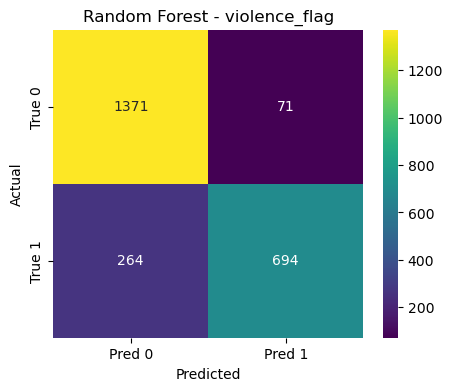

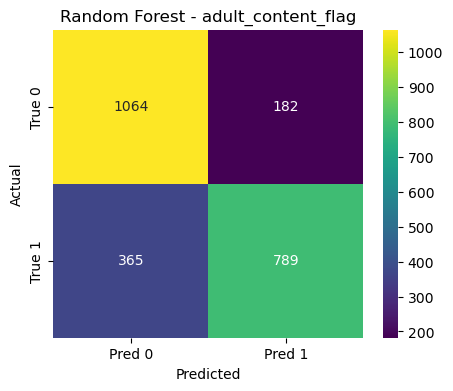

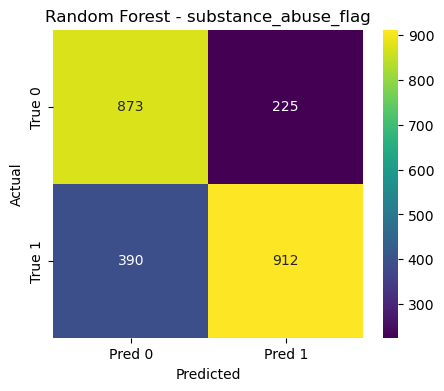

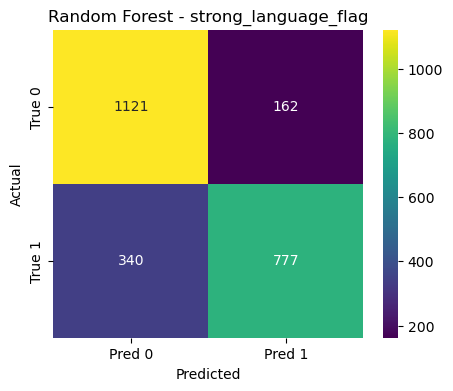

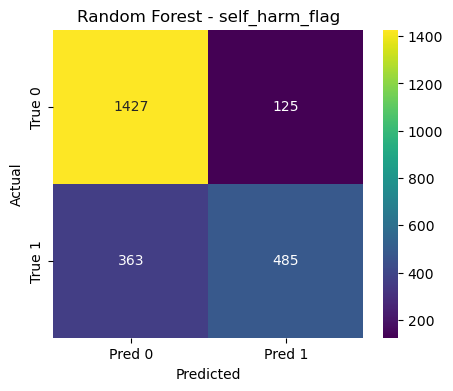

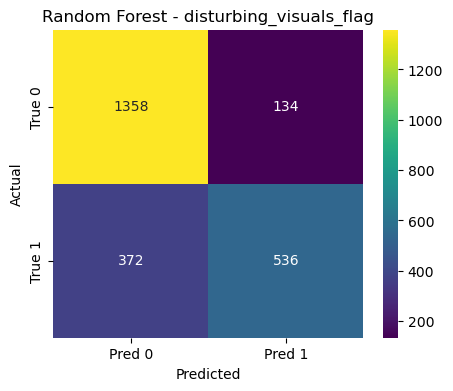

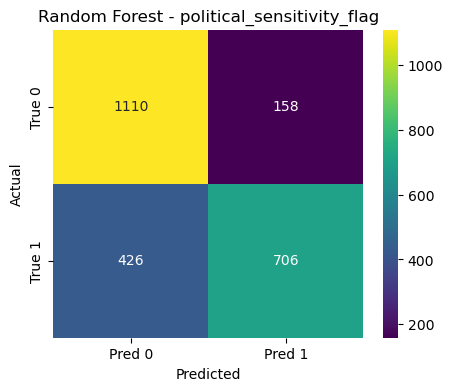

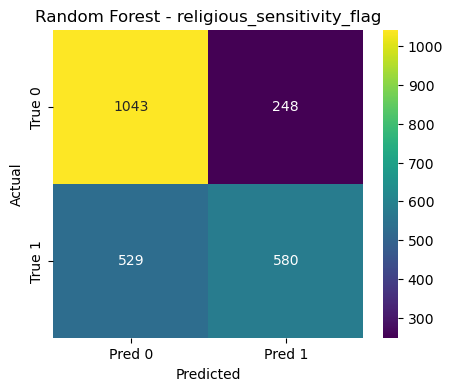

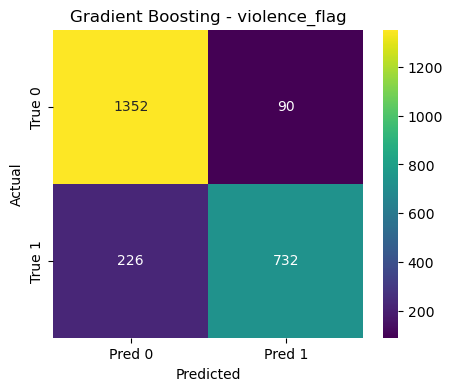

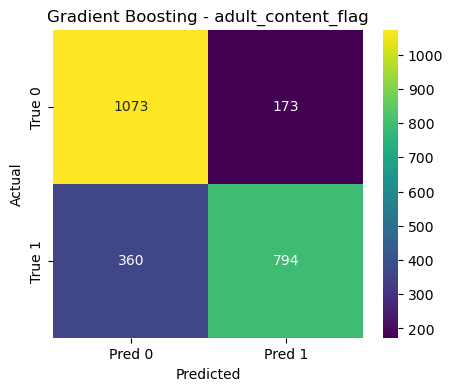

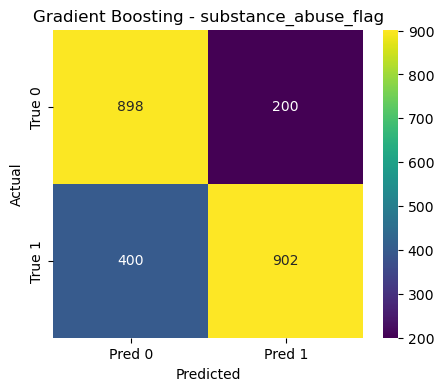

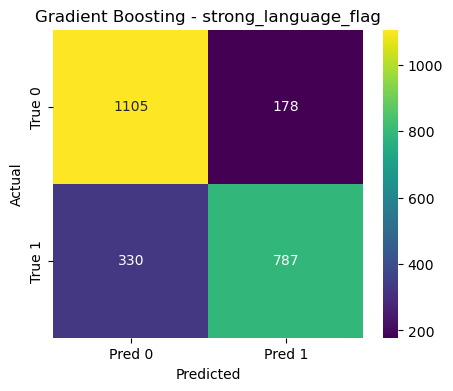

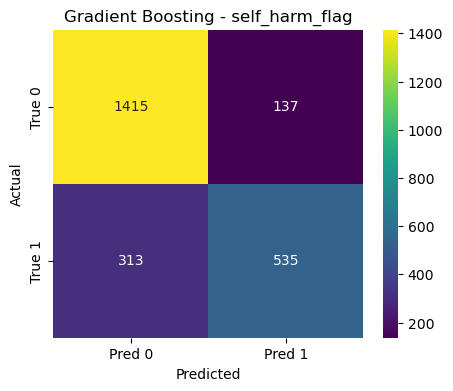

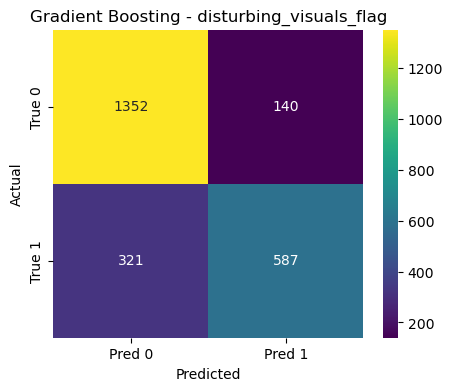

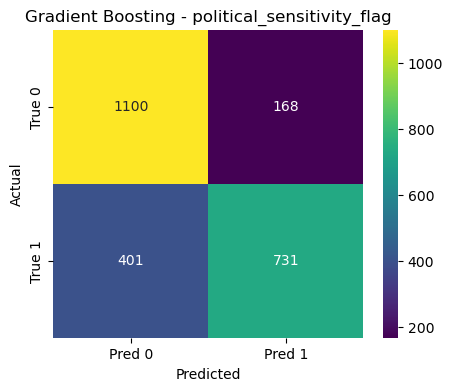

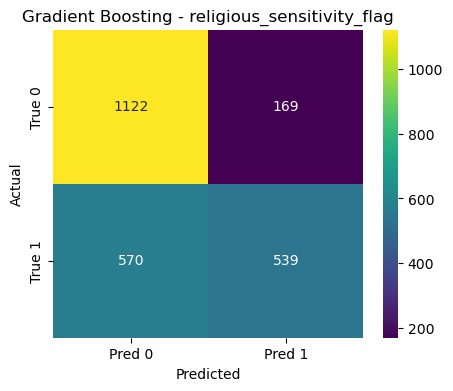

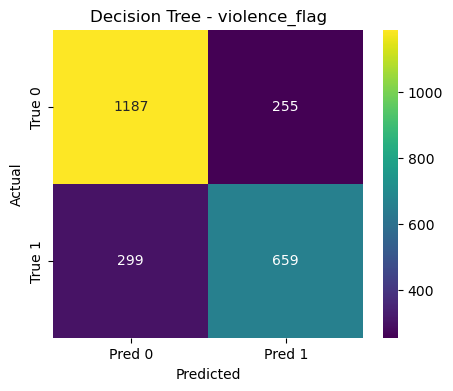

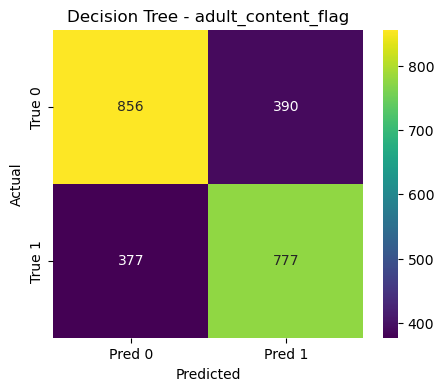

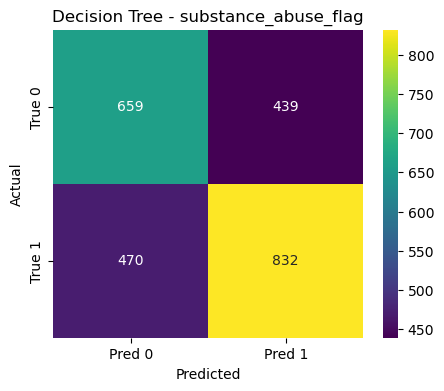

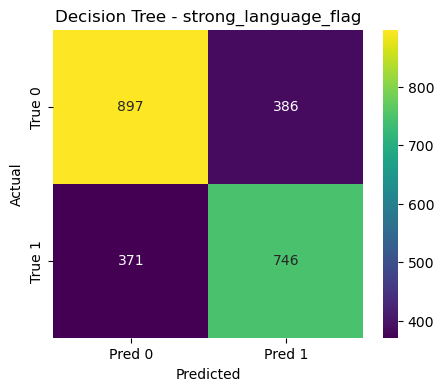

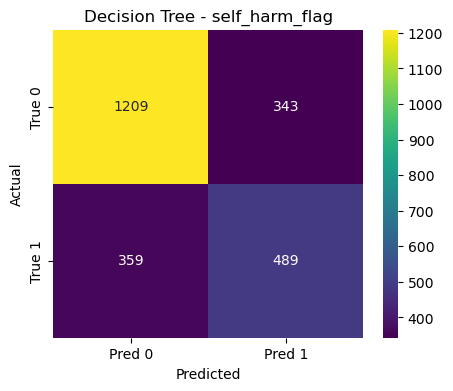

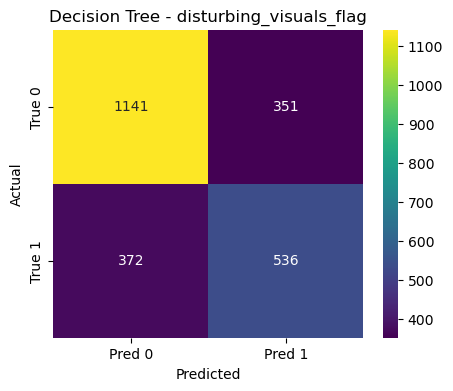

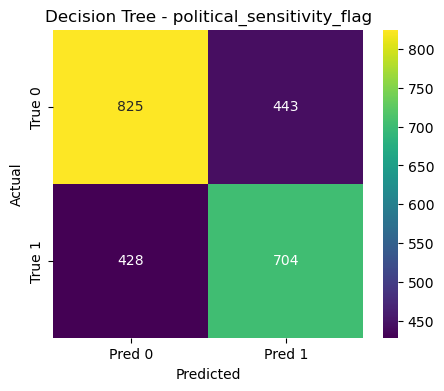

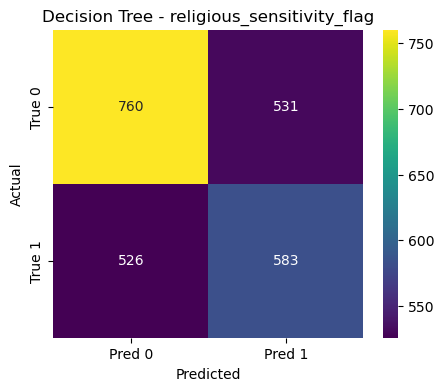

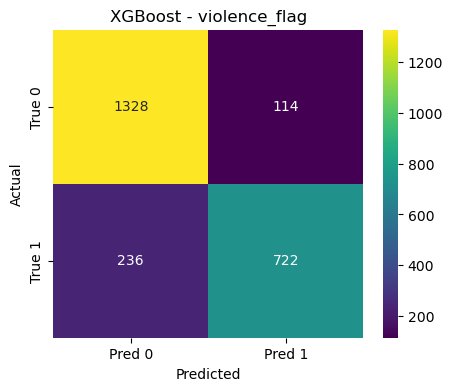

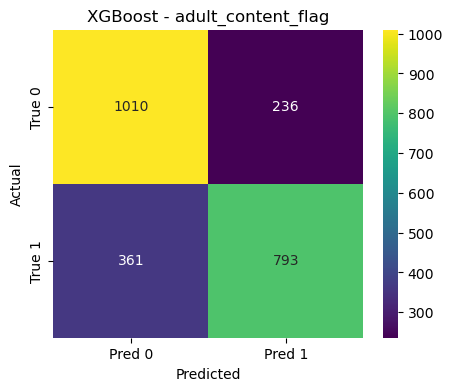

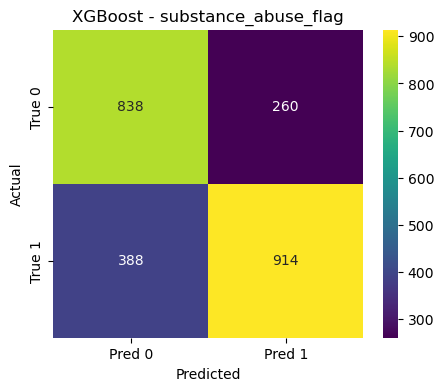

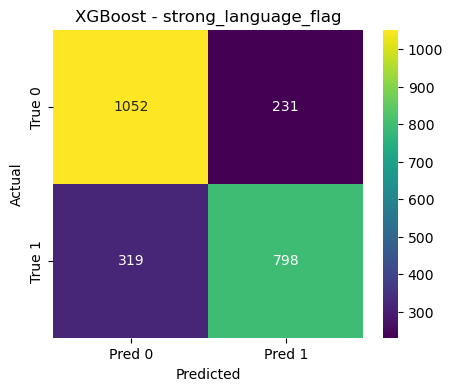

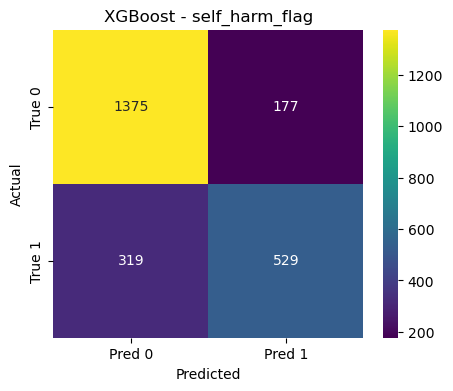

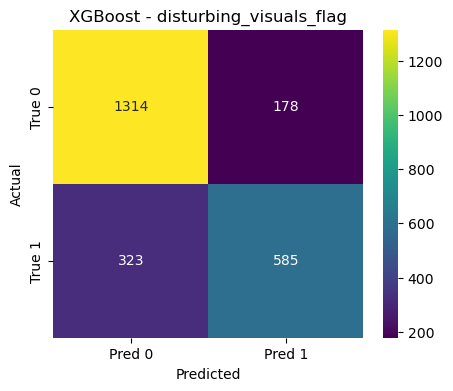

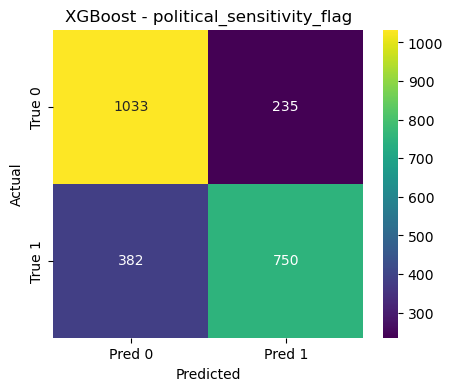

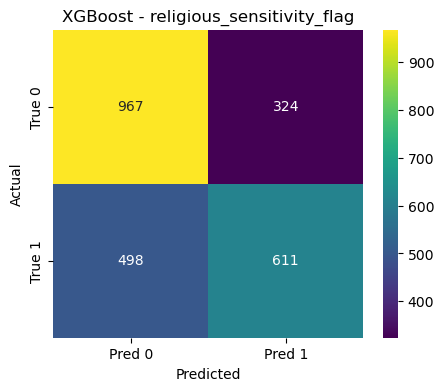

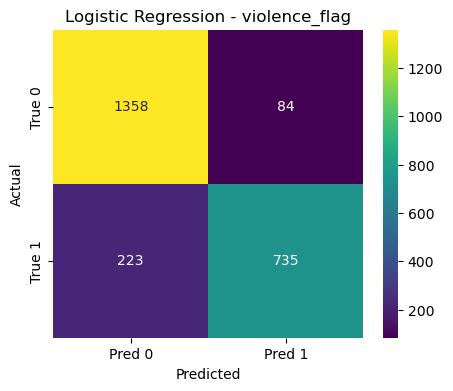

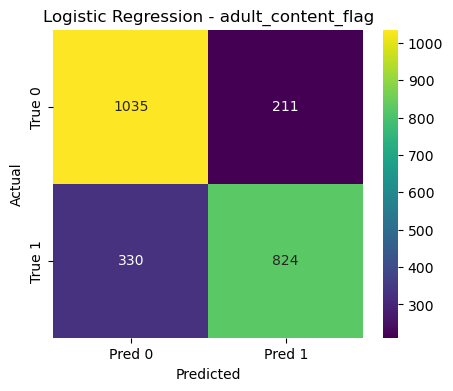

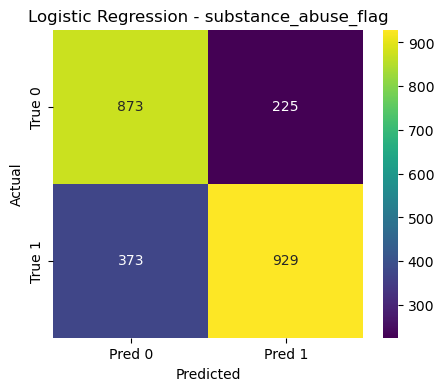

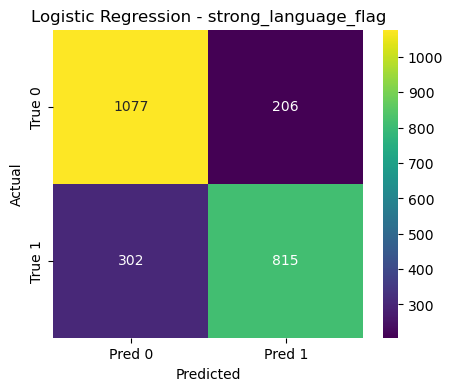

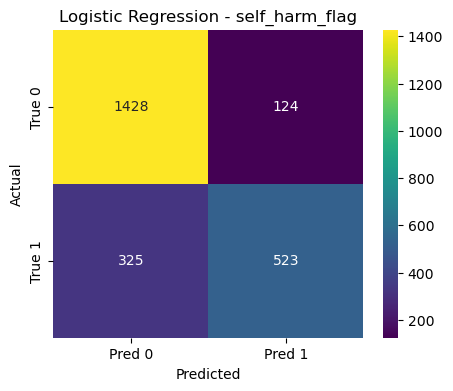

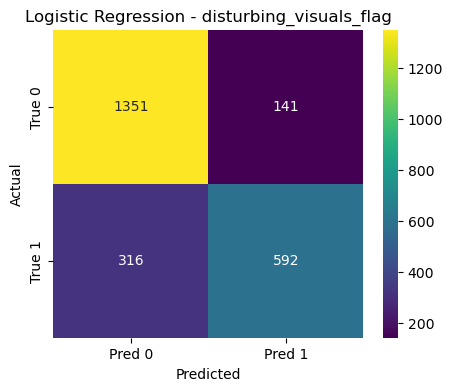

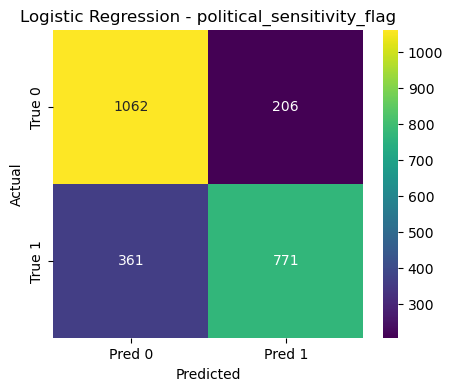

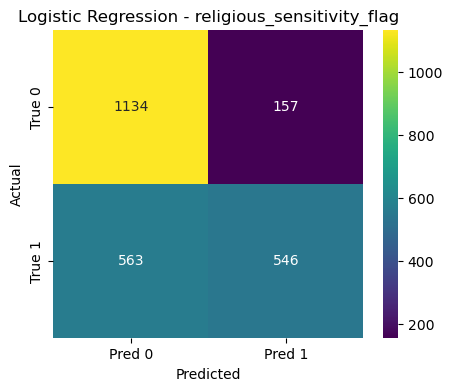

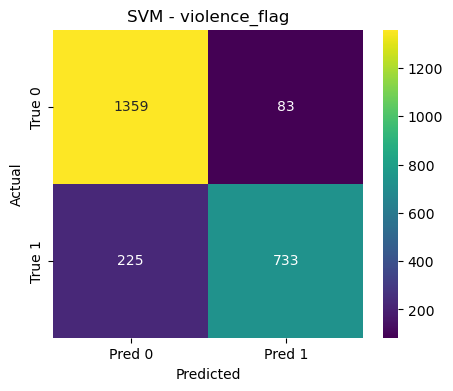

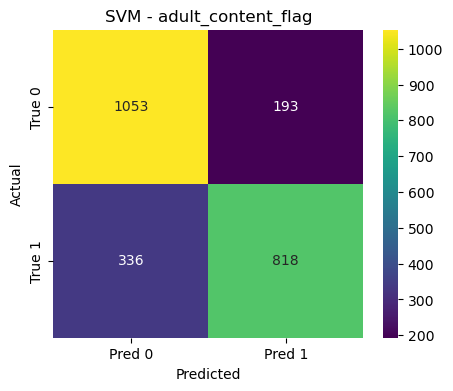

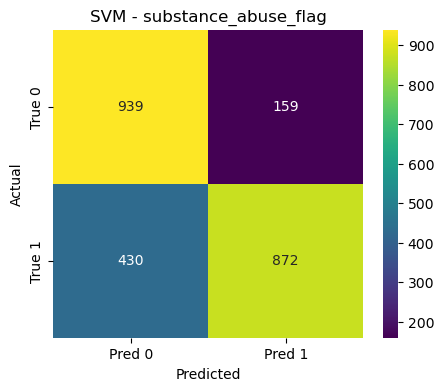

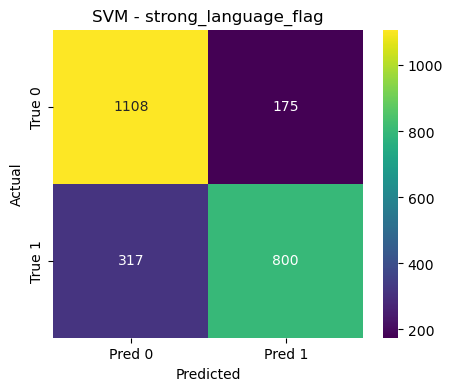

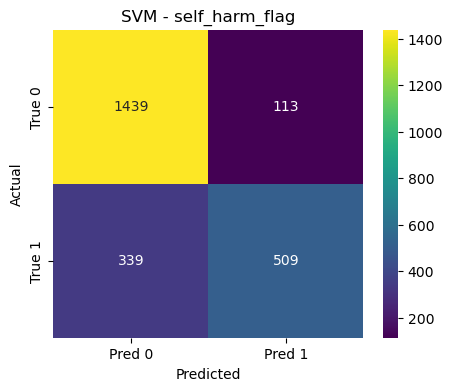

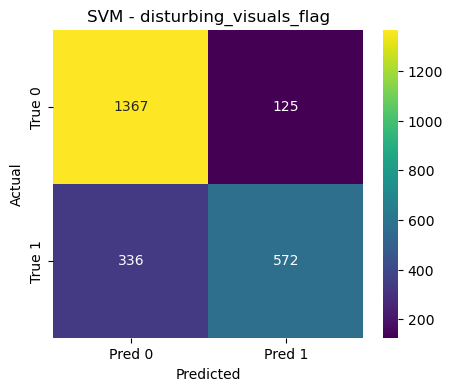

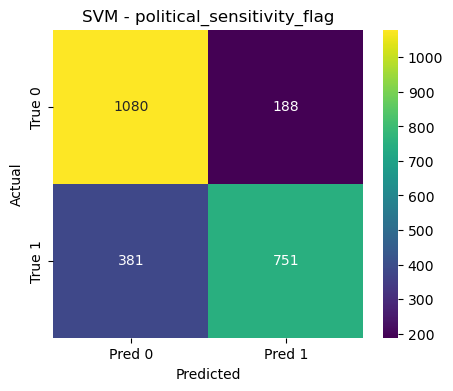

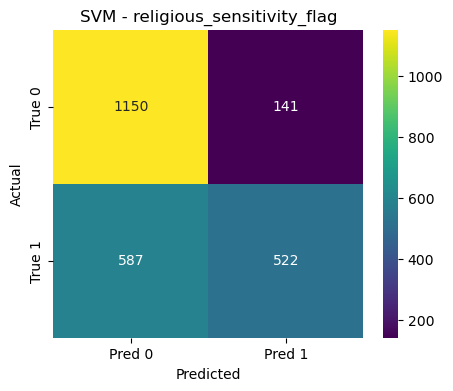

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

def plot_multilabel_confusion_matrix(model_name, y_true, y_pred, label_names):

    mcm = multilabel_confusion_matrix(y_true, y_pred)

    for i, label in enumerate(label_names):

        cm = mcm[i]

        plt.figure(figsize=(5,4))
        sns.heatmap(cm,
                    annot=True,
                    fmt='d',
                    cmap='viridis',
                    xticklabels=['Pred 0','Pred 1'],
                    yticklabels=['True 0','True 1'])

        plt.title(f"{model_name} - {label}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

        plt.show()


plot_multilabel_confusion_matrix("Random Forest", y_test, y_pred_rf, label_columns)
plot_multilabel_confusion_matrix("Gradient Boosting", y_test, y_pred_gb, label_columns)
plot_multilabel_confusion_matrix("Decision Tree", y_test, y_pred_dt, label_columns)
plot_multilabel_confusion_matrix("XGBoost", y_test, y_pred_xgb, label_columns)
plot_multilabel_confusion_matrix("Logistic Regression", y_test, y_pred_lr, label_columns)
plot_multilabel_confusion_matrix("SVM", y_test, y_pred_svm, label_columns)

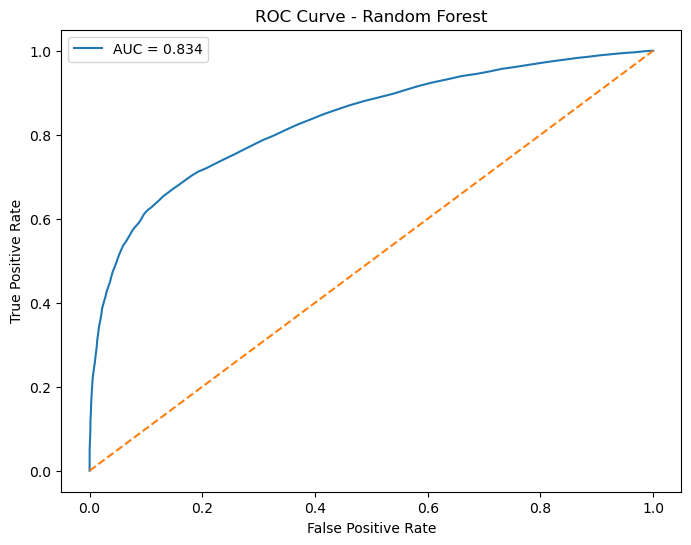

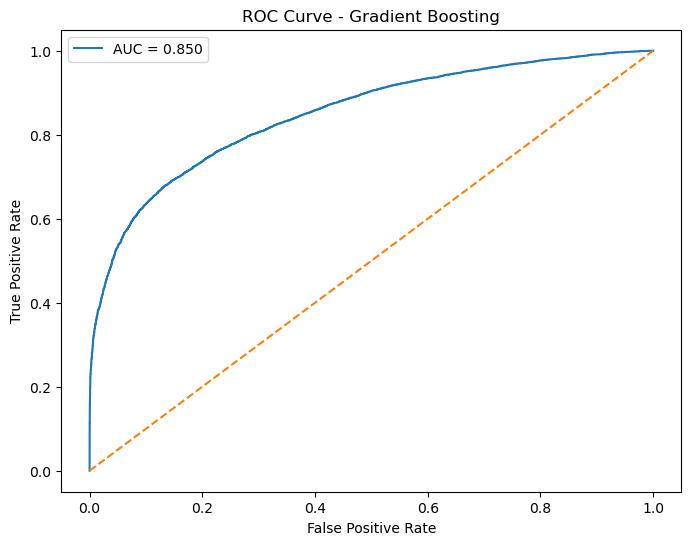

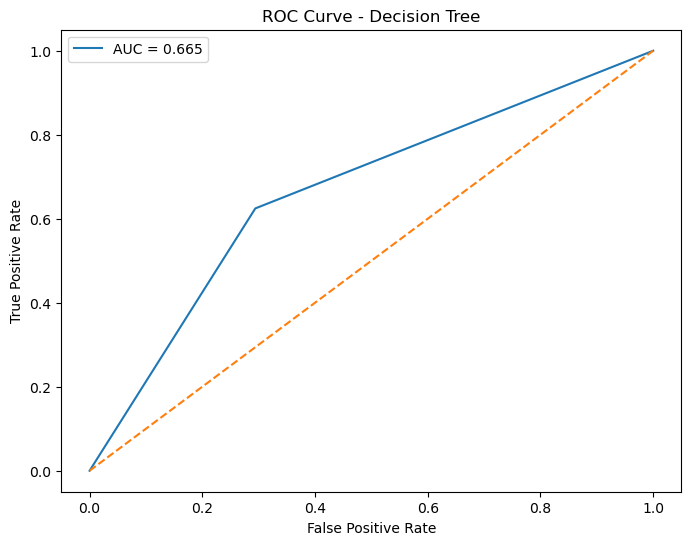

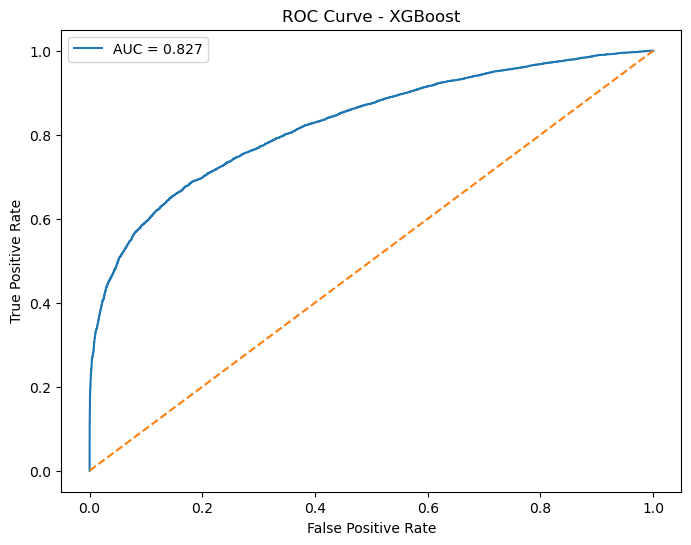

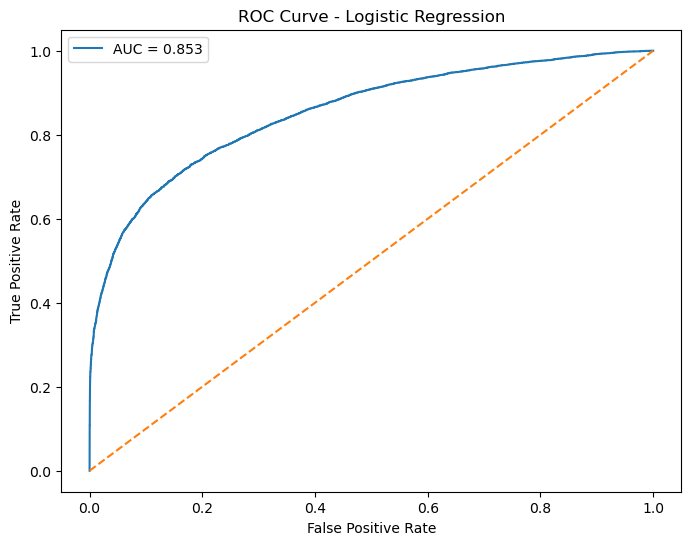

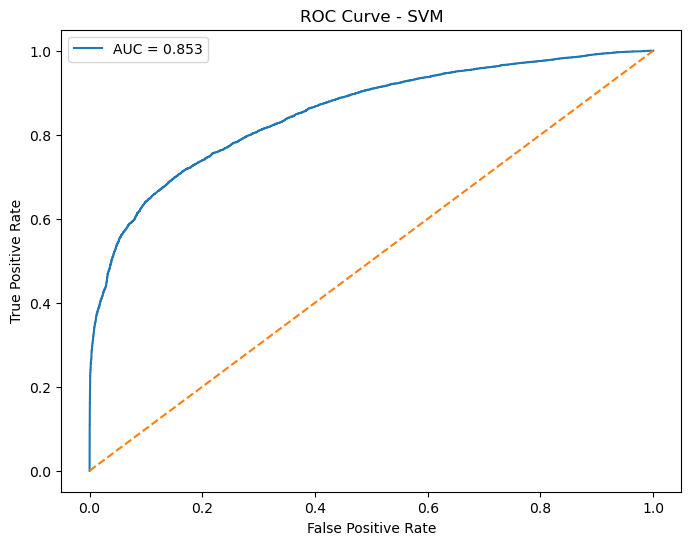

In [182]:
import numpy as np

import numpy as np

def get_probability_matrix(model, X):

    probas = model.predict_proba(X)

    # Case 1: sklearn multi-label output (list of arrays)
    if isinstance(probas, list):
        prob_matrix = np.column_stack([
            p[:,1] if p.ndim > 1 else p for p in probas
        ])

    # Case 2: already numpy matrix (XGBoost etc.)
    else:
        prob_matrix = probas

    return prob_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(model_name, y_true, y_pred_proba):

    fpr, tpr, _ = roc_curve(y_true.ravel(), y_pred_proba.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()
y_pred_rf = get_probability_matrix(rf_model, X_test)
y_pred_gb = get_probability_matrix(gb_model, X_test)
y_pred_dt = get_probability_matrix(dt_model, X_test)
y_pred_xgb = get_probability_matrix(xgb_model, X_test)
y_pred_lr = get_probability_matrix(lr_model, X_test)
y_pred_svm = get_probability_matrix(svm_model, X_test)

plot_roc_curve("Random Forest", y_test.values, y_pred_rf)
plot_roc_curve("Gradient Boosting", y_test.values, y_pred_gb)
plot_roc_curve("Decision Tree", y_test.values, y_pred_dt)
plot_roc_curve("XGBoost", y_test.values, y_pred_xgb)
plot_roc_curve("Logistic Regression", y_test.values, y_pred_lr)
plot_roc_curve("SVM", y_test.values, y_pred_svm)

**Step 10: Final Reporting**

Submit a complete report including EDA, preprocessing, modeling approach, evaluation results, and conclusions.


**OTT Content Moderation Using Multi-Label Classification**

**1. Overview**

A lot of content is hosted by over-the-top (OTT) platforms like Netflix, Amazon Prime, and Hotstar. Adult scenes, foul language, and violence may be present in certain content. It is crucial to categorise content according to various warning categories because of this.

In this project, we developed a **machine learning model to identify various content warnings automatically. The issue is handled as a **multi-label classification problem** because a single piece of content may contain multiple warnings simultaneously (such as violence and strong language).

Building models that can forecast content moderation labels based on various content features is the aim of this project.

---

**2. Dataset Description**

The dataset contains information about different content features from OTT media.

Some important features in the dataset include:

* **content_duration** – duration of the content
* **number_of_fight_scenes** – number of fight scenes
* **weapon_presence_count** – number of weapons shown
* **night_scene_ratio** – percentage of night scenes
* **number_of_curse_words** – number of abusive words
* **smoking_scene_count** – number of smoking scenes
* **alcohol_scene_count** – number of alcohol scenes
* **blood_visibility_score** – amount of visible blood
* **intimacy_scene_duration** – duration of intimate scenes
* **scream_frequency** – number of scream scenes
* **loud_noise_ratio** – loud sound percentage
* **disturbing_background_music** – disturbing music indicator
* **protest_scene_count** – protest scenes
* **religious_symbol_presence** – presence of religious symbols
* **crying_scene_duration** – crying scene duration
* **camera_shake_index** – intensity of camera movement

The dataset also contains **multiple output labels**, such as:

* violence_flag
* adult_content_flag
* substance_abuse_flag
* strong_language_flag
* self_harm_flag
* disturbing_visuals_flag
* political_sensitivity_flag
* religious_sensitivity_flag

Each label represents whether that type of content appears in the media.

---

**3. Exploratory Data Analysis (EDA)**

Exploratory Data Analysis has been carried out on the data.

**Steps performed:**

1. **Checked dataset structure**

   * Used `.info()` and `.describe()` functions.

2. **Checked missing values**

   * Verified if there are any missing values in the data.

3. **Feature distribution**

   * Observed the distribution of features like fight scenes, curse words, and alcohol scenes.

4. **Label distribution**

   * Verified the distribution of labels.

5. **Correlation analysis**

   * Observed correlation between features like violence and weapons.

---

**4. Data Preprocessing**
Prior to training these models, a series of preprocessing steps were carried out.

**1. Feature and Target Separation**

Firstly, the data is separated into two parts: one containing the features and the other containing the target.

*   **X or Features**: This part contained the content attributes.
*   **Y or Target**: This part contained the moderation attributes.

**2. Label Encoding**

Labels such as audience ratings, which are categorical data, are encoded into a numerical format using **LabelEncoder**.

**3. Train/Test Data Split**

Next, the data is split into two parts: training data and test data.

*   **80% Training Data**
*   **20% Test Data**

**4. Handling Multi-Labels for Data Points**

As each data point can have multiple labels, it is handled using **multi-label classification techniques**.

---

**5. Modeling Approach**

Various machine learning models have been trained and compared.

The models used are as follows:

1. **Random Forest**
2. **Gradient Boosting**
3. **Decision Tree**
4. **XGBoost**
5. **Logistic Regression**
6. **Support Vector Machine (SVM)**

These models have been trained using the training data set for prediction of moderation labels.

These models are attempting to learn a mapping between content features and moderation categories.

---

**6. Model Evaluation**

As this is a **Multi-label classification problem**, special evaluation metrics have been used.

**1. Hamming Loss**

Measures how many labels are incorrectly predicted.

Lower is better.

**2. Jaccard Score**

Measures how similar the predicted labels and actual labels are.

Higher is better.

**3. Micro F1 Score**

Calculates overall performance.

**4. Macro F1 Score**

Calculates individual label performances and then averages.

**5. Subset Accuracy**

Measures percentage of samples where **all labels are correctly predicted**.

**6. ROC-AUC Curve**

The ROC curve is plotted for evaluation of how good a model is in distinguishing between classes.

---

**7. Results**
After training all the models, their performance was compared based on the evaluation metrics.

General Observations:

* **Random Forest and XGBoost performed better than other models**.
* **Decision Tree performed poorer than other models due to overfitting**.
* **Logistic Regression and SVM performed moderately**.

The **complex patterns of the data were handled better by ensemble models Random Forest and XGBoost, which led to better performance**.

---

**8. Conclusion**
In this project, **a multi-label machine learning system has been developed for content moderation of OTT content categories**.

Key Findings:

* **Multi-label classification can be used for content moderation, as there can be multiple warnings for one content item**.
* **Feature engineering plays an important role for better performance of the model**.
* **Ensemble models Random Forest and XGBoost performed better than other models**.

This system can be used for **automating the detection of sensitive content categories on OTT platforms, which can be used for content filtering for age groups**.

---

**9. Future Improvements**

Future work can improve this system by:

* Using **deep learning models**
* Adding **text analysis from subtitles or scripts**
* Using **video frame analysis**
* Increasing dataset size

These improvements can make the system more accurate and practical for real-world applications.

---